# Internflare Data Analysis Project

## Objective
The goal of this project is to clean and analyze the Internflare dataset to uncover insights about service performance, revenue trends, and user behavior.

This analysis includes:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Trend analysis
- Key business insights

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Importing the dataset

In [3]:
df = pd.read_csv(r"C:\Users\HP\Documents\Data journey\Internflare\Datasets\internflare_dataset.csv")

df.head()

,Partner_ID,Partner_Name,Intern_ID,Intern_Name,Intern_Assigned_To,Service_Type,Fee_Charged,Payment_Status,Country,Start_Date,End_Date,Intern_Hours,Feedback_Rating
0,P001,CloudSoft,I1000,Nathan Stevens,CloudSoft,Branding,799USD,Paid,Nigeria,2025-04-02,2025-08-28,398.0,3
1,P005,CloudSoft,I1001,Mario Alvarez,CloudSoft,Masterclass,1621,Pending,United States,2024-08-26,2025-06-25,91.0,bad
2,P003,Alpha Tech,I1002,Shane Fuller,Alpha Tech,Masterclass,$1718,Failed,Canda,2025-05-18,2025-12-15,88.0,4
3,P008,EcoTrans,I1003,Nicholas West,EcoTrans,Analytics,USD995,Paid,Canda,2025-04-24,2025-11-22,NaN,4
4,P004,Betta Ltd.,I1004,Matthew Harper,Betta Ltd.,Web Dev,$1568,Fail,Nigeria,2023-10-06,2025-07-21,686.0,5


## Dataset Overview

Before cleaning the dataset, we explore its structure to understand:

- Number of rows and columns
- Data types
- Missing values
- Distribution of variables

In [7]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Partner_ID          3000 non-null   object 
 1   Partner_Name        3000 non-null   object 
 2   Intern_ID           3000 non-null   object 
 3   Intern_Name         2863 non-null   object 
 4   Intern_Assigned_To  3000 non-null   object 
 5   Service_Type        3000 non-null   object 
 6   Fee_Charged         3000 non-null   object 
 7   Payment_Status      3000 non-null   object 
 8   Country             3000 non-null   object 
 9   Start_Date          3000 non-null   object 
 10  End_Date            3000 non-null   object 
 11  Intern_Hours        1940 non-null   float64
 12  Feedback_Rating     2694 non-null   object 
dtypes: float64(1), object(12)
memory usage: 304.8+ KB


,Intern_Hours
count,1940.000000
mean,559.065464
std,358.169634
min,10.000000
25%,237.750000
50%,482.500000
75%,876.000000
max,1200.000000


## Missing Value Analysis

We check for missing values to determine if data imputation or removal is required.

In [8]:
df.isna().sum().sort_values(ascending = False)

Intern_Hours          1060
Feedback_Rating        306
Intern_Name            137
Partner_ID               0
Partner_Name             0
Intern_Assigned_To       0
Intern_ID                0
Service_Type             0
Fee_Charged              0
Country                  0
Payment_Status           0
End_Date                 0
Start_Date               0
dtype: int64

In [10]:
#checking this in precerntage value
df.isna().mean() * 100

Partner_ID             0.000000
Partner_Name           0.000000
Intern_ID              0.000000
Intern_Name            4.566667
Intern_Assigned_To     0.000000
Service_Type           0.000000
Fee_Charged            0.000000
Payment_Status         0.000000
Country                0.000000
Start_Date             0.000000
End_Date               0.000000
Intern_Hours          35.333333
Feedback_Rating       10.200000
dtype: float64

## Data Cleaning

The following steps were performed:

- Removed duplicate records
- Handled missing values
- Converted date columns to datetime
- Corrected inconsistent categorical values

In [11]:
#making a copy of our dataset for cleaning
data = df.copy()

## Handling Missing Values

- Intern_Name Column
- Replace missing values with 'Unknown'

In [12]:
data['Intern_Name'].fillna('Unknown', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_16960\1134844684.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Intern_Name'].fillna('Unknown', inplace=True)


## Handling Missing Values

- Feedback_Rating Column

### Assuming these rating style

- 5 = Excellent
- 4 = Verygood
- 3 = Good
- 2 = bad
- 1 = poor

### Convert to numerical data type

pd.to_numeric()

### Check for distribution and skewness

Bimodal in nature, thus, filling nan with mean or mode won't be the best idea

### Checking for Outliers

There are no outliers, so we'll fill with the median of the columns

In [14]:
data['Feedback_Rating'].value_counts().sort_values(ascending = False)

Feedback_Rating
5            320
4            314
1            312
excellent    300
poor         298
Good         293
bad          292
2            283
3            282
Name: count, dtype: int64

In [17]:
data['Feedback_Rating'].replace({'excellent': '5', 'poor': '1', 'Good': '3', 'bad': '2'}, inplace=True)

In [18]:
data['Feedback_Rating'].value_counts().sort_values(ascending = False)

Feedback_Rating
5    620
1    610
3    575
2    575
4    314
Name: count, dtype: int64

In [19]:
data['Feedback_Rating'] = pd.to_numeric(data['Feedback_Rating'])

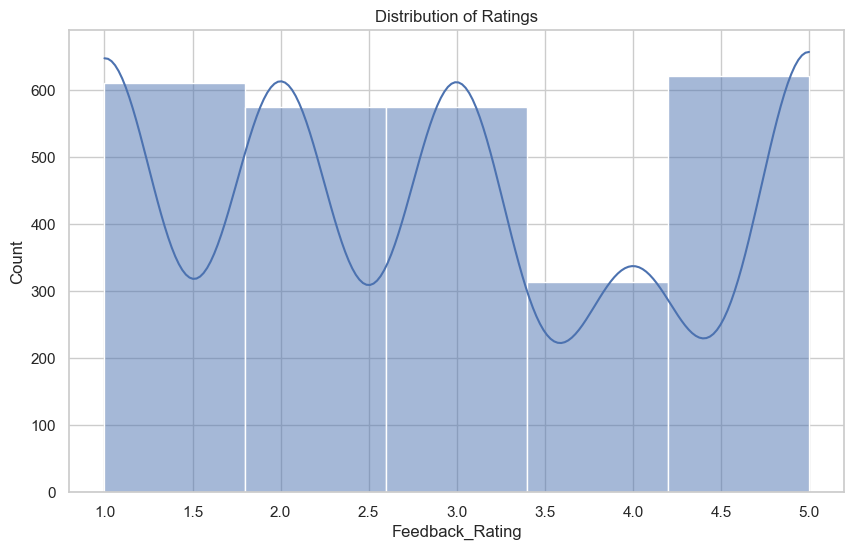

In [24]:
sns.histplot(data['Feedback_Rating'], kde = True,bins = 5)
plt.title('Distribution of Ratings')
plt.savefig('Distribution of Feedback Ratings', dpi=300)

plt.show()

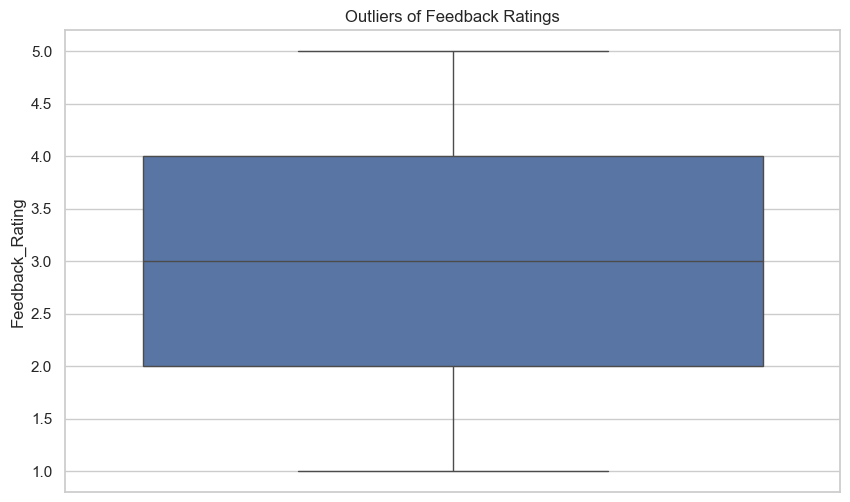

In [26]:
sns.boxplot(data['Feedback_Rating'])
plt.title('Outliers of Feedback Ratings')
plt.savefig('Boxplot of Feedback Ratings', dpi=300)

plt.show()

In [27]:
data['Feedback_Rating'].fillna(data['Feedback_Rating'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_16960\3744152046.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Feedback_Rating'].fillna(data['Feedback_Rating'].median(), inplace=True)


## Handling Missing Values

- Intern Hours Column

### Check for distribution and skewness

Bimodal in nature, thus, filling nan with mean or mode won't be the best idea

### Checking for Outliers

There are no outliers, so we'll fill with the median of the columns

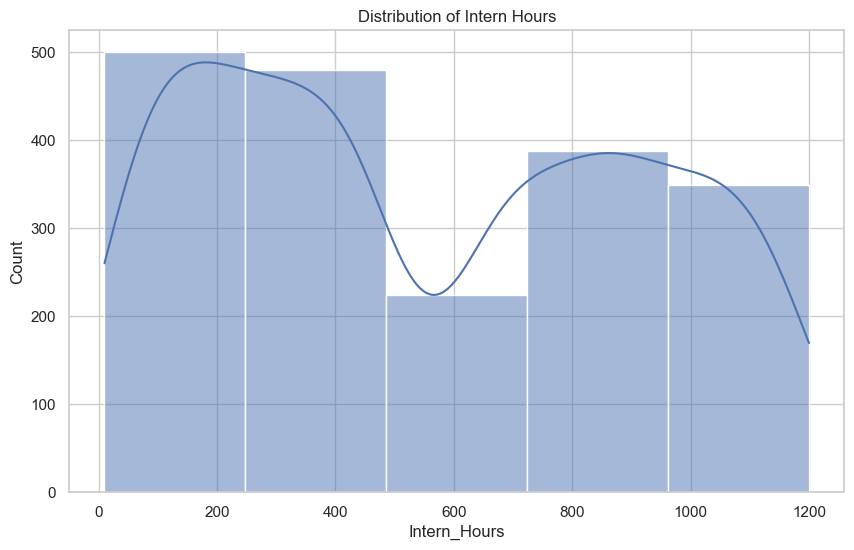

In [28]:
sns.histplot(data['Intern_Hours'], kde = True,bins = 5)
plt.title('Distribution of Intern Hours')
plt.savefig('Distribution of Intern Hours', dpi=300)

plt.show()

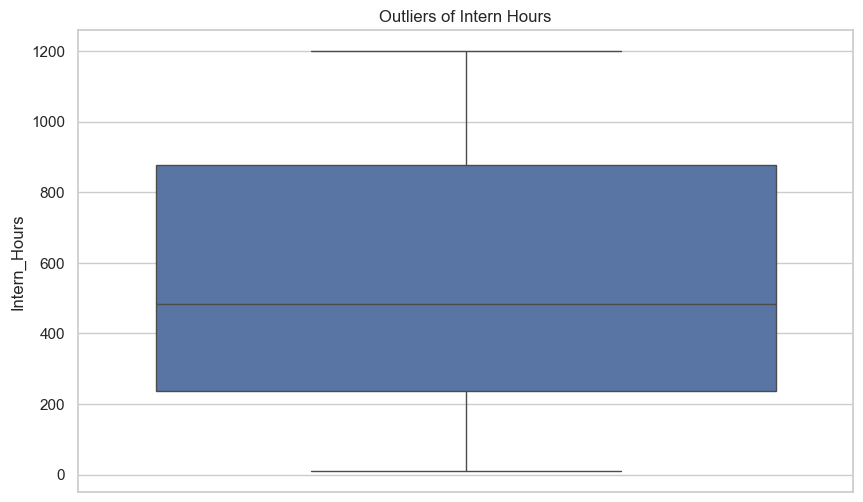

In [29]:
sns.boxplot(data['Intern_Hours'])
plt.title('Outliers of Intern Hours')
plt.savefig('Boxplot of Intern Hours', dpi=300)

plt.show()

In [30]:
data['Intern_Hours'].fillna(data['Intern_Hours'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_16960\1841253171.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Intern_Hours'].fillna(data['Intern_Hours'].median(), inplace=True)


## Handling duplicates

In [31]:
data.duplicated().sum()

np.int64(0)

## Convert Date columns to datetime

In [32]:
data['Start_Date'] = pd.to_datetime(data['Start_Date'])

In [33]:
data['End_Date'] = pd.to_datetime(data['End_Date'])

## Handling Inconsistencies

- Country column
- Payment Status column
- Fee_charged column

In [34]:
data['Country'].value_counts()

Country
UK               318
Nigeria          317
U.K.             317
United States    308
Germany          304
Canada           291
Nig              290
USA              287
Canda            285
Naija            283
Name: count, dtype: int64

In [35]:
#fixing the inconsistencies in the country column
data['Country'] = data['Country'].replace({'U.K.':'United Kingdom', 'UK': 'United Kingdom', 'USA': 'United States',
                                           'Canda': 'Canada', 'Nig': 'Nigeria', 'Naija': 'Nigeria'})

In [36]:
data['Country'].value_counts()

Country
Nigeria           890
United Kingdom    635
United States     595
Canada            576
Germany           304
Name: count, dtype: int64

In [37]:
data['Payment_Status'].value_counts()

Payment_Status
Pending    637
Paid       602
Fail       598
Pendig     591
Failed     572
Name: count, dtype: int64

In [38]:
data['Payment_Status'] = data['Payment_Status'].replace({'Fail': 'Failed', 'Pendig': 'Pending'})

In [39]:
data['Payment_Status'].value_counts()

Payment_Status
Pending    1228
Failed     1170
Paid        602
Name: count, dtype: int64

In [40]:
data['Fee_Charged'].value_counts()

Fee_Charged
191        4
1144       4
1080       4
1057       4
USD1455    4
          ..
431USD     1
USD1711    1
1848USD    1
1921USD    1
274USD     1
Name: count, Length: 2477, dtype: int64

In [41]:
#using regex to extract only the numbers from this column
import re

In [42]:
data['Fee_Charged'] = data['Fee_Charged'].str.replace(r'[^\d]', '', regex=True)

In [43]:
#convert to numeric
data['Fee_Charged'] = pd.to_numeric(data['Fee_Charged'])

In [44]:
data.head()

,Partner_ID,Partner_Name,Intern_ID,Intern_Name,Intern_Assigned_To,Service_Type,Fee_Charged,Payment_Status,Country,Start_Date,End_Date,Intern_Hours,Feedback_Rating
0,P001,CloudSoft,I1000,Nathan Stevens,CloudSoft,Branding,799,Paid,Nigeria,2025-04-02,2025-08-28,398.0,3.0
1,P005,CloudSoft,I1001,Mario Alvarez,CloudSoft,Masterclass,1621,Pending,United States,2024-08-26,2025-06-25,91.0,2.0
2,P003,Alpha Tech,I1002,Shane Fuller,Alpha Tech,Masterclass,1718,Failed,Canada,2025-05-18,2025-12-15,88.0,4.0
3,P008,EcoTrans,I1003,Nicholas West,EcoTrans,Analytics,995,Paid,Canada,2025-04-24,2025-11-22,482.5,4.0
4,P004,Betta Ltd.,I1004,Matthew Harper,Betta Ltd.,Web Dev,1568,Failed,Nigeria,2023-10-06,2025-07-21,686.0,5.0


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Partner_ID          3000 non-null   object        
 1   Partner_Name        3000 non-null   object        
 2   Intern_ID           3000 non-null   object        
 3   Intern_Name         3000 non-null   object        
 4   Intern_Assigned_To  3000 non-null   object        
 5   Service_Type        3000 non-null   object        
 6   Fee_Charged         3000 non-null   int64         
 7   Payment_Status      3000 non-null   object        
 8   Country             3000 non-null   object        
 9   Start_Date          3000 non-null   datetime64[ns]
 10  End_Date            3000 non-null   datetime64[ns]
 11  Intern_Hours        3000 non-null   float64       
 12  Feedback_Rating     3000 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), obje

In [46]:
data.to_csv('cleaned_internflare.csv', index=False)